# (14) Predictive performance: MNIST

host = ```any```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Load model (MNIST)

In [3]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)', 'kms-(256,8,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_dtheta-15_yoru-0_(2025_09_09,1
4:07)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_11,10:20)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_11,12:21)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-2_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_12,18:09)'
]

In [ ]:
fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(2025_09_11,12:21)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
tr.print()

## generate: from prior pred

In [ ]:
feeder = tr.get_feeder('vld', data_batch_sz=1_000)

## sanity check for the loaded model

In [3]:
from analysis.final import get_root_path

fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(2025_09_11,12:21)'
tr, meta = load_model_lite(pjoin(get_root_path(), fit), device=device)
tr.print()

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_<ngd|lin>
b100-ep100-lr(0.0005)_temp(0.05)_gr(250)_(2025_09_11,12:21)

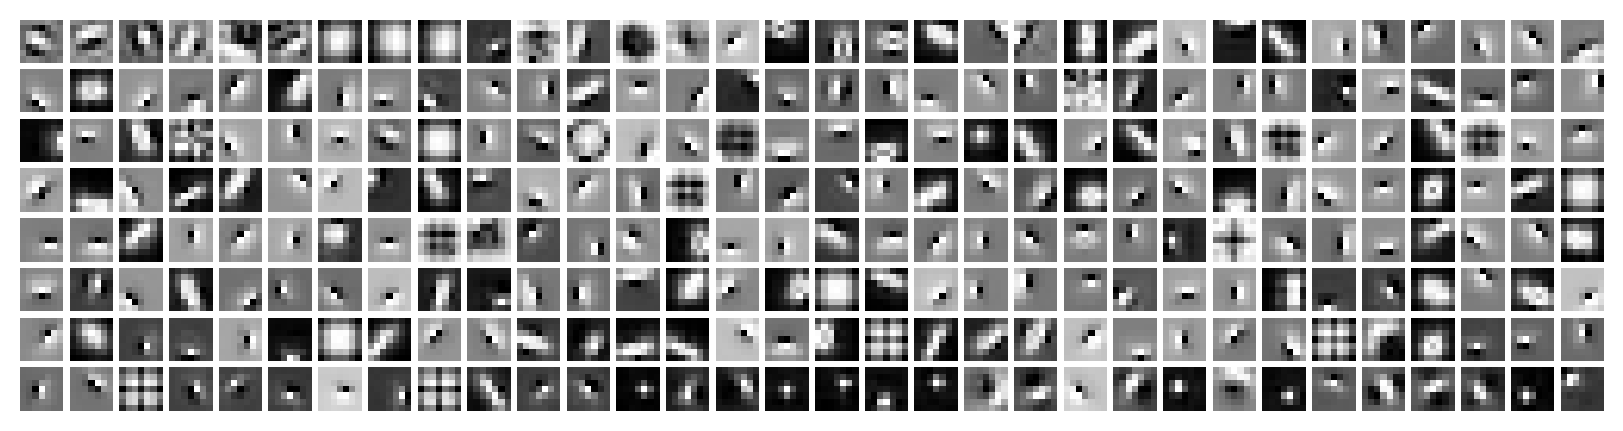

In [4]:
tr.model.show(order='u0');

In [5]:
dt_str = '\n'.join([
    f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
    f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
])
print(dt_str)

dt_enc = 0.335
dt_fwd = 1.092

In [ ]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

batch #29, (t = 678):  28%|██▊       | 28/100 [01:29<03:38,  3.04s/it]